# Titanic Data Analysis

## Objective
The goal of this project is to analyze the Titanic dataset and identify the key factors that influenced passenger survival.

We will explore how features such as gender, age, passenger class, and family size affected survival rates.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
df=pd.read_csv("titanic_dataset.csv")
df.head()

## Data Understanding

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

## Data Overview

- The dataset contains information about passengers such as age, gender, class, and fare.
- Some columns have missing values:
  - Age: 177
  - Cabin: 687
  - Embarked: 2

## Data Cleaning


In [ ]:
# Fill age with Median
df['Age']=df['Age'].fillna(df['Age'].median())

# Fill Embarked with mode
df['Port']=df['Port'].fillna(df['Port'].mode())

# Drop Cabin as there are alot missing values
df.drop('Cabin', axis=1, inplace=True)

- Filled missing Age values using median
- Filled Embarked with mode
- Dropped Cabin column due to too many missing values

## Plots


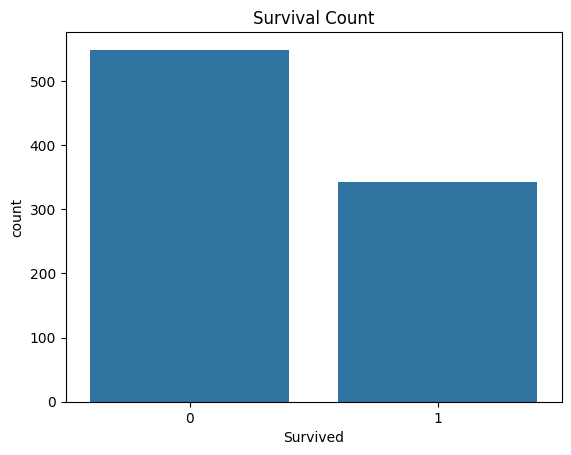

In [38]:
## Survival Count
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.show()

### Insight
The number of passengers who did not survive is higher than those who survived.

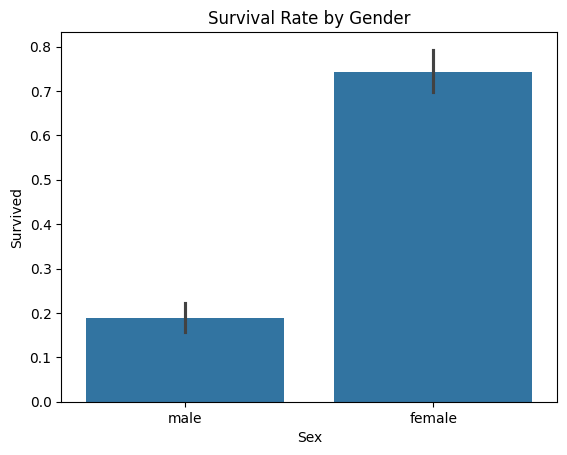

In [39]:
## Gender vs Survival Count

sns.barplot(x='Sex',y='Survived',data=df)
plt.title('Survival Rate by Gender')
plt.show()

### Insight
Females had a significantly higher survival rate than males.

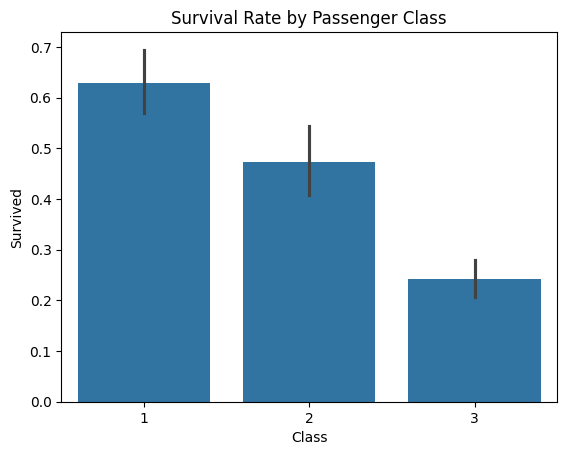

In [40]:
# Passenger Class vs Survival

sns.barplot(x='Class',y='Survived', data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

### Insight
Passengers in 1st class had a higher survival rate compared to 2nd and 3rd class.

## Age Analysis

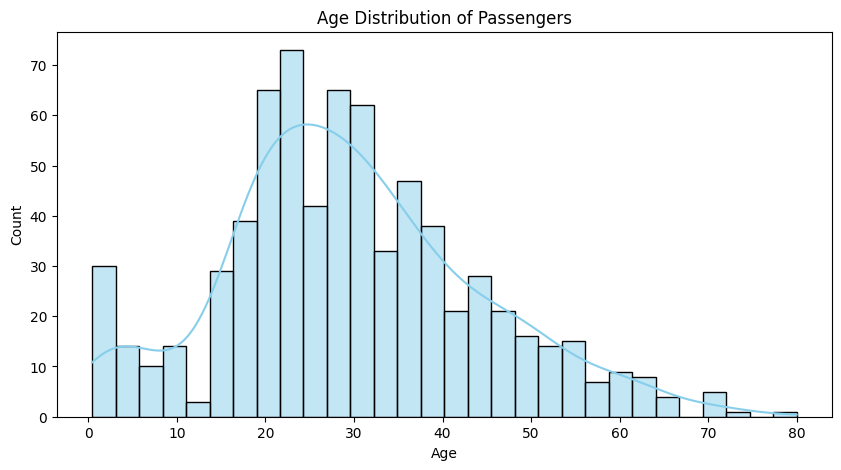

In [41]:
plt.figure(figsize=(10,5))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

C:\Users\abdul\AppData\Local\Temp\ipykernel_18416\1127103719.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df['Survived']==1, 'Age'], shade=True, label='Survived', color='green')
C:\Users\abdul\AppData\Local\Temp\ipykernel_18416\1127103719.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df['Survived']==0, 'Age'], shade=True, label='Not Survived', color='red')


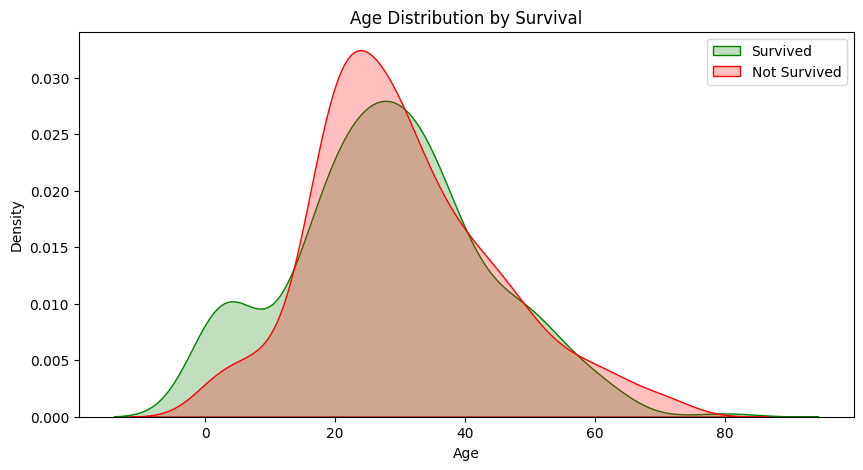

In [42]:
## Age vs Survival
plt.figure(figsize=(10,5))
sns.kdeplot(df.loc[df['Survived']==1, 'Age'], shade=True, label='Survived', color='green')
sns.kdeplot(df.loc[df['Survived']==0, 'Age'], shade=True, label='Not Survived', color='red')
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.show()

### Insight
- Children and younger adults had slightly better survival chances.
- Most deaths occurred among middle-aged adults.

# Feature Engineering

C:\Users\abdul\AppData\Local\Temp\ipykernel_18416\4152560798.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FamilySize', y='Survived', data=df, palette='viridis')


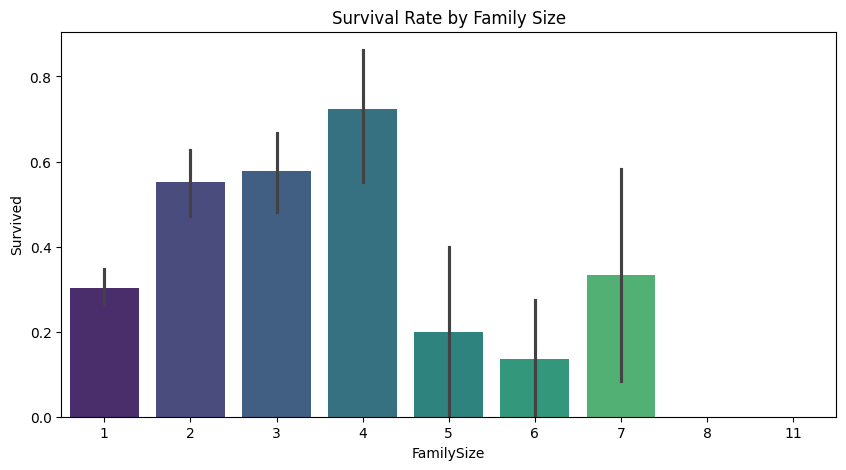

In [43]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['IsAlone'] = 1
df.loc[df['FamilySize'] > 1, 'IsAlone'] = 0

plt.figure(figsize=(10,5))
sns.barplot(x='FamilySize', y='Survived', data=df, palette='viridis')
plt.title("Survival Rate by Family Size")
plt.show()

### Insight
- Passengers with small families (2-4 members) had better survival chances.
- Those traveling alone or in very large families had lower survival rates.

### Class + Gender vs Survival

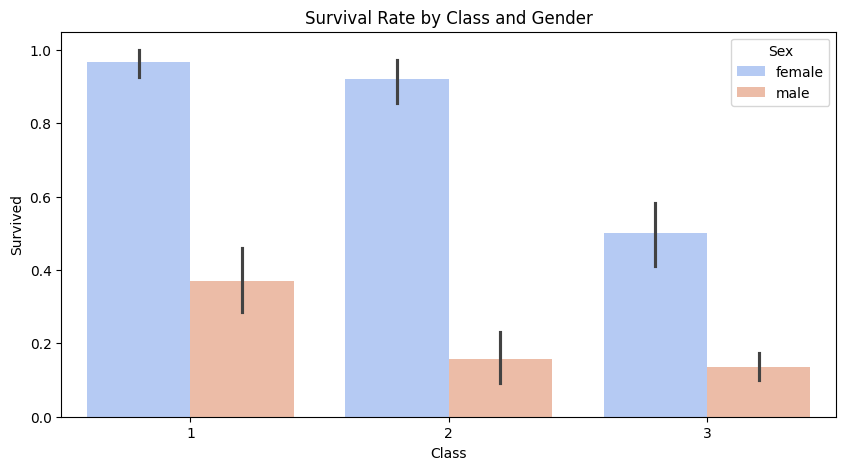

In [44]:
plt.figure(figsize=(10,5))
sns.barplot(x='Class',y='Survived',hue='Sex',data=df,palette='coolwarm')
plt.title('Survival Rate by Class and Gender')
plt.show()

### Insight
- Females survived more than males in all classes.
- 1st class females had the highest survival rate.
- 3rd class males had the lowest survival rate.

## Fare vs Survival

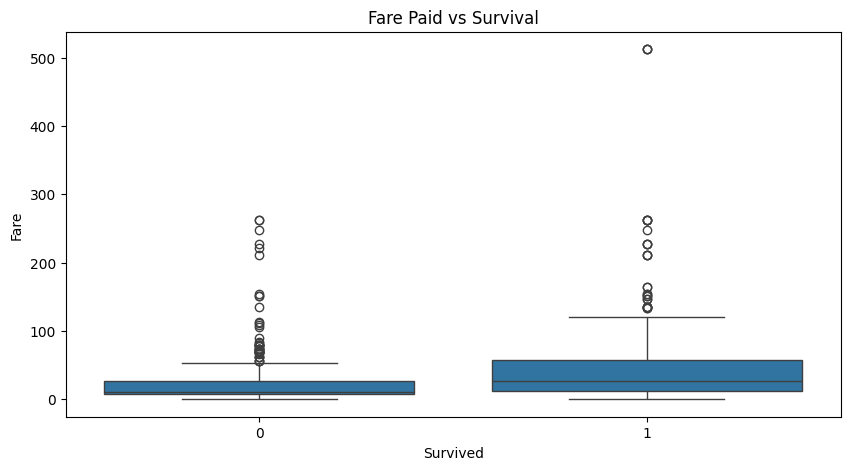

In [45]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Survived',y='Fare',data=df)
plt.title('Fare Paid vs Survival')
plt.show()

### Insight
- Passengers who paid higher fares (likely higher class) had better survival chances.
- Lower-fare passengers were more at risk.

## Embarked Analysis

C:\Users\abdul\AppData\Local\Temp\ipykernel_18416\548252081.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Port', y='Survived', data=df, palette='magma')


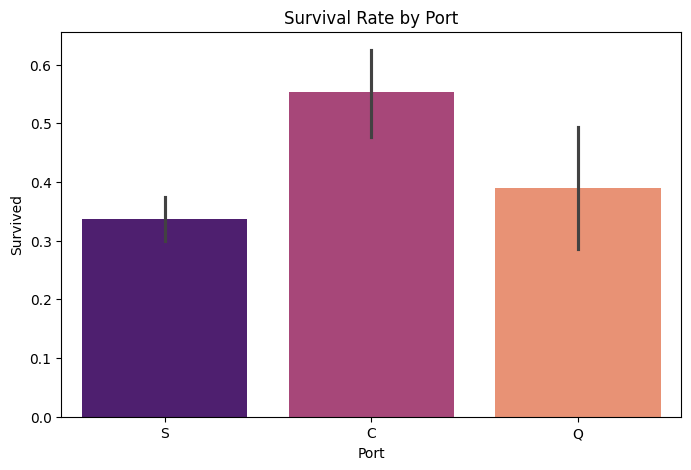

In [46]:
plt.figure(figsize=(8,5))
sns.barplot(x='Port', y='Survived', data=df, palette='magma')
plt.title("Survival Rate by Port")
plt.show()

### Insight
- Passengers who boarded at certain ports had slightly better survival rates.
- Port C had the highest survival rate.

## Coorelation Heaptmap


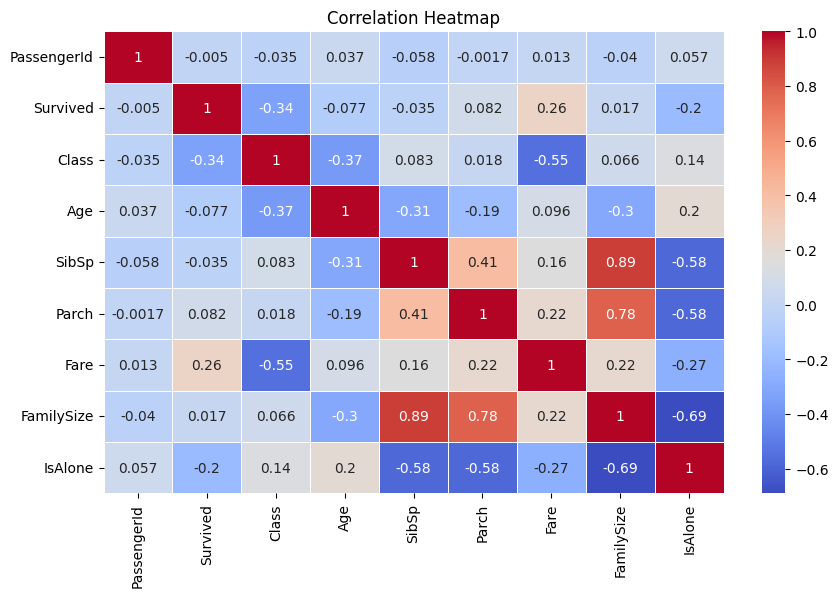

In [47]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Insight
- Class and Fare are negatively correlated with survival (higher class/fare → better survival)
- FamilySize and IsAlone have expected relationships with survival

## Key Insights

1. Gender was the strongest factor: Females survived much more than males.
2. Passenger class influenced survival: 1st class passengers had the highest survival.
3. Age had an impact: Children and younger adults had slightly higher survival chances.
4. Family size mattered: Small families survived better; very large families or alone had lower survival.
5. Fare and socio-economic status were related to survival chances.
6. Port of embarkation had a minor effect on survival.


## Conclusion

The Titanic survival analysis shows that gender, passenger class, family size, and socio-economic status played key roles in survival rates.  
This project demonstrates **exploratory data analysis, feature engineering, and visualization skills** — essential for a Data Analyst portfolio.